### Extension E - Semantic Signal Recovery

**Subtitle:** *Training-free multi-interest reranking*

The 64-dimensional adapter and sequence encoder discard part of the original
1536-dimensional content signal. This extension restores that signal at inference
by directly matching a candidate against the user's frozen history embeddings.

Alternative titles:

- Full-Dimensional Semantic Reranking
- Multi-Interest Semantic Scoring
- Recovering Discarded Content Signal

### Extension F - Popularity-Aware Expert Routing

**Subtitle:** *Suppress noisy collaboration for cold candidates*

The dual-view score already contains a collaborative expert and a semantic expert.
Cold candidates are routed away from the poorly trained collaborative component,
while popular candidates retain the full dual-view score.

Alternative titles:

- Cold-Item Specialist Routing
- Adaptive Dual-View Routing
- Candidate-Level Semantic Routing

##  story

> **Recover, then route.** Extension E restores full-dimensional semantic evidence.
> Extension F decides when the collaborative view should be trusted.

All figures are exported with transparent backgrounds as PNG and SVG.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Circle

OUTPUT_DIR = Path("poster_assets") / "headline_extensions"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

E_COLOR = "#B94545"
E_LIGHT = "#F6DDDD"
F_COLOR = "#D94D9A"
F_LIGHT = "#F8DDEE"
BLUE = "#2D78B7"
BLUE_DARK = "#174F7A"
BLUE_LIGHT = "#DCECF7"
GRAY = "#8F969F"
DARK = "#26364A"
GREEN = "#3A9D68"
ORANGE = "#E69F27"

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 240,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.alpha": 0.22,
    "grid.linewidth": 0.8,
    "legend.frameon": False,
})

def save_figure(fig, stem):
    png = OUTPUT_DIR / f"{stem}.png"
    svg = OUTPUT_DIR / f"{stem}.svg"
    fig.savefig(png, bbox_inches="tight", facecolor="none", transparent=True)
    fig.savefig(svg, bbox_inches="tight", facecolor="none", transparent=True)
    print(f"Saved: {png} and {svg}")

def box(ax, xy, width, height, text, face, edge, fontsize=11, weight="normal"):
    patch = FancyBboxPatch(
        xy, width, height,
        boxstyle="round,pad=0.018,rounding_size=0.025",
        facecolor=face, edgecolor=edge, linewidth=1.8
    )
    ax.add_patch(patch)
    ax.text(
        xy[0] + width/2, xy[1] + height/2, text,
        ha="center", va="center", fontsize=fontsize,
        fontweight=weight, color=DARK
    )
    return patch

def arrow(ax, start, end, color=DARK, lw=1.8):
    ax.add_patch(FancyArrowPatch(
        start, end, arrowstyle="-|>", mutation_scale=14,
        linewidth=lw, color=color
    ))

print(f"Assets: {OUTPUT_DIR.resolve()}")

Assets: C:\Users\AnkieF\Desktop\LLM-ESR-EXT\poster_assets\headline_extensions


## Data used in the prototypes

All main E/F comparisons use the authors' released datasets, three backbones, five
seeds per cell, and inference-time evaluation on frozen checkpoints.

In [2]:
datasets = ["Yelp", "Fashion", "Beauty"]
backbones = ["SASRec", "GRU4Rec", "BERT4Rec"]

# Extension E: max-pool semantic scoring, gamma=16, delta HR@10 vs base model.
e_overall = pd.DataFrame(
    [
        [0.0041, 0.0130, 0.0061],
        [0.0235, 0.0244, 0.0293],
        [0.0273, 0.0381, 0.0312],
    ],
    index=datasets, columns=backbones
)

e_tail = pd.DataFrame(
    [
        [0.0160, 0.0104, 0.0135],
        [0.0523, 0.0431, 0.0586],
        [0.0815, 0.0557, 0.0416],
    ],
    index=datasets, columns=backbones
)

# Mean-profile D6 comparison for the profile-choice prototype.
e_mean_overall = pd.DataFrame(
    [
        [0.0020, 0.0092, 0.0035],
        [0.0186, 0.0184, 0.0224],
        [0.0083, 0.0194, 0.0147],
    ],
    index=datasets, columns=backbones
)

# Extension F: default per-candidate hard router, delta HR@10 vs full+max.
f_default = pd.DataFrame(
    [
        [0.0020, 0.0140, 0.0004],
        [0.0273, 0.0336, 0.0293],
        [0.0047, 0.0270, 0.0269],
    ],
    index=datasets, columns=backbones
)

# Best validation-tuned threshold/variant, retaining default where it is better.
f_tuned = pd.DataFrame(
    [
        [0.0020, 0.0183, 0.0022],
        [0.0354, 0.0488, 0.0401],
        [0.0084, 0.0632, 0.0618],
    ],
    index=datasets, columns=backbones
)

# Stage-1 diagnostic: semantic-only minus full+max on tail-user x tail-item.
f_cold_advantage = pd.Series(
    [0.018, 0.042, 0.088], index=datasets,
    name="Semantic-only advantage"
)

# Router variant results across all 9 cells.
f_user_gate = np.array([-0.0595, -0.0691, -0.0763, 0.0138, 0.0243, 0.0193, -0.0674, -0.0317, -0.0257])
f_soft_gate = np.array([0.0018, 0.0081, 0.0022, 0.0081, 0.0087, 0.0077, 0.0021, 0.0126, 0.0081])
f_default_vals = f_default.to_numpy().ravel()
f_tuned_vals = f_tuned.to_numpy().ravel()

# Extension E - Semantic Signal Recovery

## Results: semantic recovery gains

Grouped dot plots show the gain from max-pool semantic matching for every dataset-backbone setting. Separate panels keep the smaller overall gains and larger tail-item gains readable.

Saved: poster_assets\headline_extensions\extension_E_gains_dotplot.png and poster_assets\headline_extensions\extension_E_gains_dotplot.svg


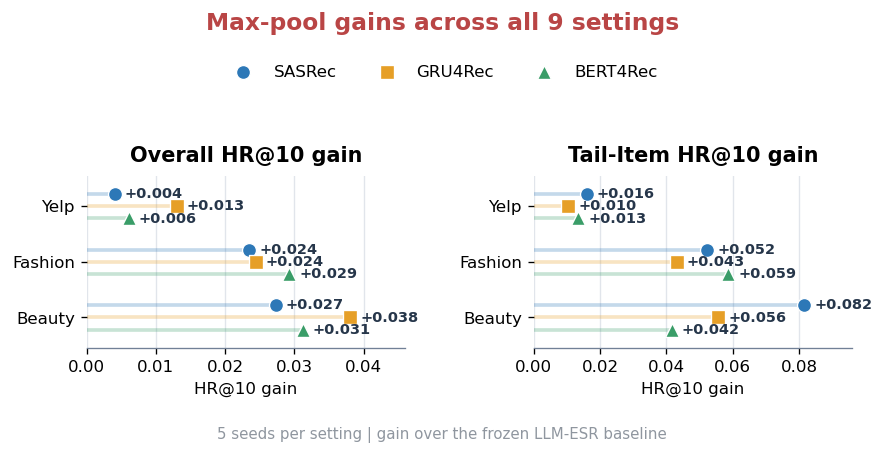

In [3]:

backbone_colors = [BLUE, ORANGE, GREEN]
backbone_markers = ["o", "s", "^"]


def grouped_gain_dots(ax, frame, title, xmax):
    y_base = np.arange(len(datasets))
    offsets = [-0.22, 0.0, 0.22]

    for offset, backbone, color, marker in zip(
        offsets, backbones, backbone_colors, backbone_markers
    ):
        values = frame[backbone].to_numpy()
        y = y_base + offset
        ax.hlines(y, 0, values, color=color, linewidth=2.2, alpha=0.28, zorder=1)
        ax.scatter(
            values,
            y,
            s=70,
            marker=marker,
            color=color,
            edgecolor="white",
            linewidth=0.8,
            label=backbone,
            zorder=3,
        )
        for value, ypos in zip(values, y):
            ax.annotate(
                f"+{value:.3f}",
                (value, ypos),
                xytext=(6, 0),
                textcoords="offset points",
                ha="left",
                va="center",
                fontsize=8.7,
                fontweight="bold",
                color=DARK,
            )

    ax.set_title(title, fontsize=12.5, fontweight="bold", pad=8)
    ax.set_xlim(0, xmax)
    ax.set_ylim(-0.55, len(datasets) - 0.45)
    ax.set_yticks(y_base, datasets)
    ax.invert_yaxis()
    ax.set_xlabel("HR@10 gain", fontsize=10)
    ax.set_axisbelow(True)
    ax.grid(axis="x", color="#D7DDE5", linewidth=0.8, alpha=0.75)
    ax.grid(axis="y", visible=False)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color("#718096")
    ax.tick_params(axis="both", labelsize=10)


fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.15))
grouped_gain_dots(axes[0], e_overall, "Overall HR@10 gain", 0.046)
grouped_gain_dots(axes[1], e_tail, "Tail-Item HR@10 gain", 0.096)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    frameon=False,
    fontsize=10,
)
fig.suptitle(
    "Max-pool gains across all 9 settings",
    fontsize=14,
    fontweight="bold",
    color=E_COLOR,
    y=1.12,
)
fig.text(
    0.5,
    -0.01,
    "5 seeds per setting | gain over the frozen LLM-ESR baseline",
    ha="center",
    fontsize=9,
    color=GRAY,
)
fig.tight_layout(rect=(0, 0.05, 1, 0.93), w_pad=2.2)
save_figure(fig, "extension_E_gains_dotplot")
plt.show()


## Optional supporting visual: why max-pool?

Every point above the diagonal means the max-pool profile improves overall HR@10
more than the simple mean profile on the same backbone/dataset cell.

Saved: poster_assets\headline_extensions\extension_E_profile_comparison.png and poster_assets\headline_extensions\extension_E_profile_comparison.svg


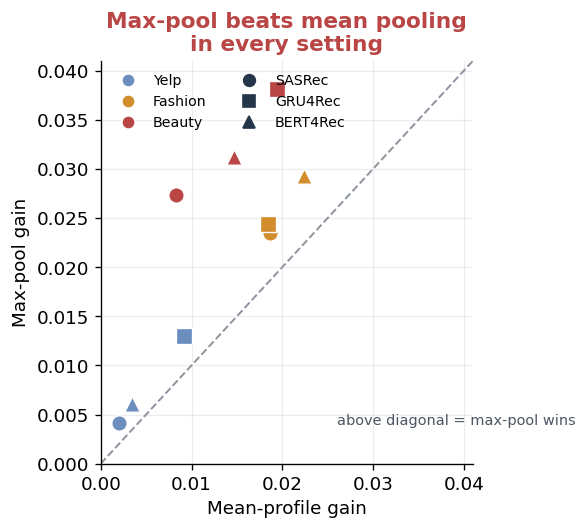

In [4]:
fig, ax = plt.subplots(figsize=(4.8, 4.55))
dataset_colors = {"Yelp": "#6C8EBF", "Fashion": "#D28E2D", "Beauty": E_COLOR}
markers = {"SASRec": "o", "GRU4Rec": "s", "BERT4Rec": "^"}

for dataset in datasets:
    for backbone in backbones:
        xval = e_mean_overall.loc[dataset, backbone]
        yval = e_overall.loc[dataset, backbone]
        ax.scatter(
            xval, yval, s=85, marker=markers[backbone],
            color=dataset_colors[dataset], edgecolor="white", linewidth=0.8
        )

limit = 0.041
ax.plot([0, limit], [0, limit], ls="--", color=GRAY, lw=1.2)
ax.set_xlim(0, limit)
ax.set_ylim(0, limit)
ax.set_xlabel("Mean-profile gain")
ax.set_ylabel("Max-pool gain")
ax.set_title("Max-pool beats mean pooling\nin every setting",
             fontweight="bold", fontsize=13, color=E_COLOR)

legend_handles = [
    plt.Line2D([0], [0], marker="o", color="none", markerfacecolor=dataset_colors[d],
               markeredgecolor="white", markersize=8, label=d)
    for d in datasets
] + [
    plt.Line2D([0], [0], marker=markers[b], color=DARK, linestyle="none",
               markersize=7, label=b)
    for b in backbones
]
ax.legend(handles=legend_handles, ncol=2, fontsize=8.5, loc="upper left")
ax.text(0.026, 0.004, "above diagonal = max-pool wins",
        fontsize=8.7, color="#4B5563")
fig.tight_layout()

save_figure(fig, "extension_E_profile_comparison")
plt.show()

# Extension F - Popularity-Aware Expert Routing


## Diagnostic: why route?

This compact plot explains the mechanism before showing the final router result.
For cold-user x cold-item cases, semantic-only scoring beats the full model plus
max-pool on all three datasets.

Saved: poster_assets\headline_extensions\extension_F_cold_item_diagnostic.png and poster_assets\headline_extensions\extension_F_cold_item_diagnostic.svg


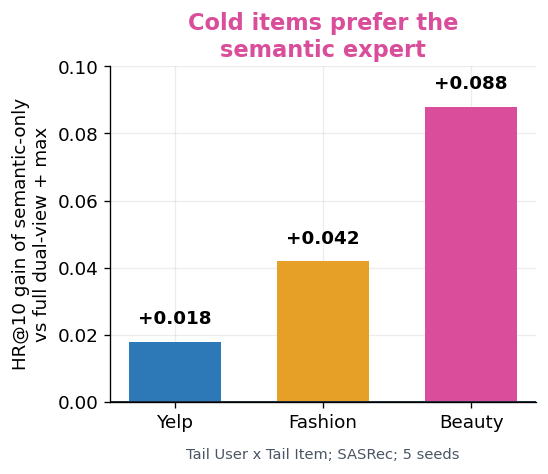

In [5]:
fig, ax = plt.subplots(figsize=(4.7, 4.15))
bars = ax.bar(
    f_cold_advantage.index, f_cold_advantage.values,
    color=[BLUE, ORANGE, F_COLOR], width=0.62
)
ax.axhline(0, color=DARK, lw=1.2)
ax.set_ylabel("HR@10 gain of semantic-only\nvs full dual-view + max")
ax.set_title("Cold items prefer the\nsemantic expert",
             fontsize=13.5, fontweight="bold", color=F_COLOR)
ax.set_ylim(0, 0.100)
for bar, value in zip(bars, f_cold_advantage.values):
    ax.text(bar.get_x() + bar.get_width()/2, value + 0.004,
            f"+{value:.3f}", ha="center", va="bottom",
            fontsize=11, fontweight="bold")
ax.text(0.5, -0.17, "Tail User x Tail Item; SASRec; 5 seeds",
        transform=ax.transAxes, ha="center", fontsize=8.8, color="#4B5563")
fig.tight_layout()

save_figure(fig, "extension_F_cold_item_diagnostic")
plt.show()

## Results: routing gains over Extension E

Grouped dot plots compare the default routing threshold with the validation-tuned threshold. A shared scale makes the extra benefit of tuning directly comparable.

Saved: poster_assets\headline_extensions\extension_F_router_dotplot.png and poster_assets\headline_extensions\extension_F_router_dotplot.svg


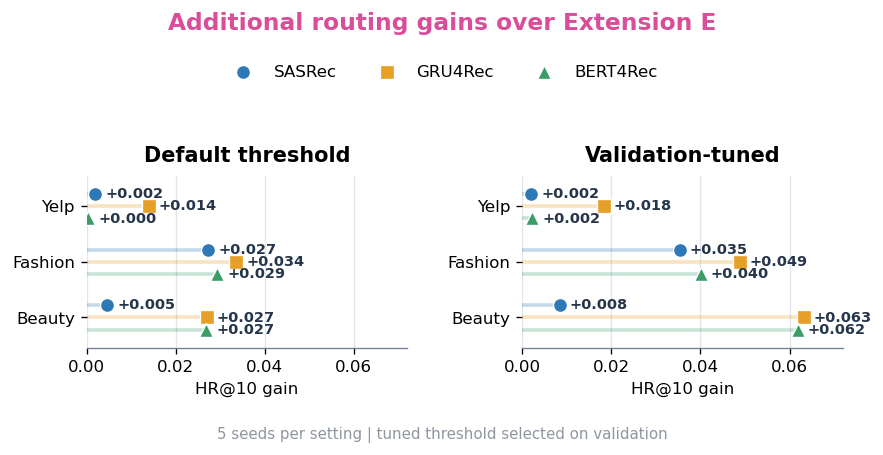

In [6]:

fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.15))

grouped_gain_dots(
    axes[0],
    f_default,
    "Default threshold",
    0.072,
)
grouped_gain_dots(
    axes[1],
    f_tuned,
    "Validation-tuned",
    0.072,
)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    frameon=False,
    fontsize=10,
)
fig.suptitle(
    "Additional routing gains over Extension E",
    fontsize=14,
    fontweight="bold",
    color=F_COLOR,
    y=1.12,
)
fig.text(
    0.5,
    -0.01,
    "5 seeds per setting | tuned threshold selected on validation",
    ha="center",
    fontsize=9,
    color=GRAY,
)
fig.tight_layout(rect=(0, 0.05, 1, 0.93), w_pad=2.2)
save_figure(fig, "extension_F_router_dotplot")
plt.show()


## Optional supporting visual: routing granularity

This plot is useful if the poster needs to explain why the route must be
**per candidate**, not per user. Points show the nine backbone x dataset cells;
the bar is the mean.

Saved: poster_assets\headline_extensions\extension_F_router_variants.png and poster_assets\headline_extensions\extension_F_router_variants.svg


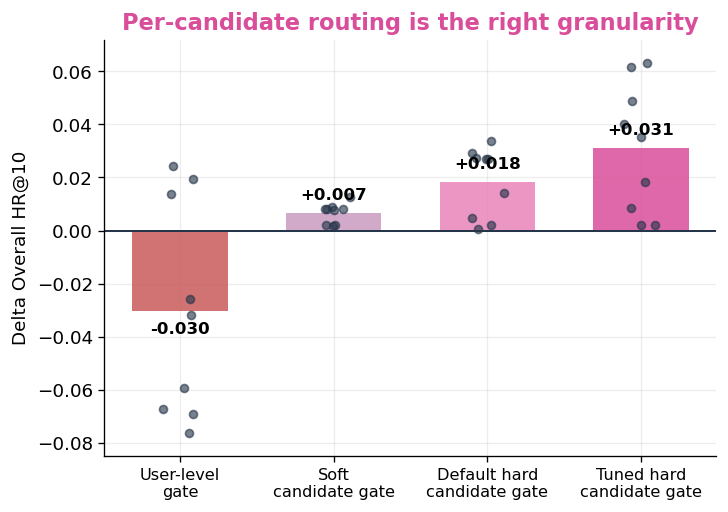

In [7]:
variant_data = {
    "User-level\ngate": f_user_gate,
    "Soft\ncandidate gate": f_soft_gate,
    "Default hard\ncandidate gate": f_default_vals,
    "Tuned hard\ncandidate gate": f_tuned_vals,
}

fig, ax = plt.subplots(figsize=(6.2, 4.4))
positions = np.arange(len(variant_data))
means = np.array([values.mean() for values in variant_data.values()])
bar_colors = ["#C95A5A", "#C99BC0", "#E884B9", F_COLOR]
ax.bar(positions, means, color=bar_colors, width=0.62, alpha=0.85)

rng = np.random.default_rng(7)
for xpos, values in zip(positions, variant_data.values()):
    jitter = rng.uniform(-0.11, 0.11, len(values))
    ax.scatter(np.full(len(values), xpos) + jitter, values, s=23,
               color=DARK, alpha=0.62, zorder=3)

ax.axhline(0, color=DARK, lw=1.2)
ax.set_xticks(positions, variant_data.keys(), fontsize=9.7)
ax.set_ylabel("Delta Overall HR@10")
ax.set_title("Per-candidate routing is the right granularity",
             fontsize=13.5, fontweight="bold", color=F_COLOR)
ax.set_ylim(-0.085, 0.072)
for xpos, value in zip(positions, means):
    ax.text(xpos, value + (0.004 if value >= 0 else -0.004),
            f"{value:+.3f}", ha="center",
            va="bottom" if value >= 0 else "top",
            fontweight="bold", fontsize=10)
fig.tight_layout()

save_figure(fig, "extension_F_router_variants")
plt.show()